# 📗 Notebook 2 — Data Loading & EDA
## Exploratory Data Analysis + Preprocessing Pipeline

This notebook:
1. Loads and cleans the dataset
2. Performs exploratory data analysis (EDA)
3. Creates the train / val / test splits
4. Builds the PyTorch `Dataset` and `DataLoader` classes

## 2.1 Run Configuration First
Make sure you have run **Notebook 1** or re-run the config cell below.

In [1]:
import os, torch, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
warnings.filterwarnings('ignore')

# ── Config (copy from Notebook 1) ─────────────────────────
DATA_PATH      = "suicide_detection.csv"
OUTPUT_DIR     = "outputs"; os.makedirs(OUTPUT_DIR, exist_ok=True)
TEXT_COLUMN    = "text";  LABEL_COLUMN = "class"
LABEL_MAP      = {"suicide": 1, "non-suicide": 0}
TEST_SIZE      = 0.15;  VAL_SIZE = 0.15;  RANDOM_SEED = 42
MAX_LENGTH     = 512;   BATCH_SIZE = 16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Config loaded. Device:", DEVICE)

Config loaded. Device: cpu


## 2.2 Load & Clean Dataset
The CSV has a row-index column (col 0), a `text` column, and a `class` column with values `suicide` / `non-suicide`.

In [2]:
def load_dataset(path):
    df = pd.read_csv(path, index_col=0)
    df = df[[TEXT_COLUMN, LABEL_COLUMN]].copy()
    df.dropna(inplace=True)
    df.drop_duplicates(subset=[TEXT_COLUMN], inplace=True)
    df[LABEL_COLUMN] = df[LABEL_COLUMN].str.strip().map(LABEL_MAP)
    df.dropna(subset=[LABEL_COLUMN], inplace=True)
    df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(int)
    return df

df = load_dataset(DATA_PATH)
print(f"Total samples     : {len(df):,}")
print(f"Suicide     (1)   : {df[LABEL_COLUMN].sum():,}  ({df[LABEL_COLUMN].mean()*100:.1f}%)")
print(f"Non-suicide (0)   : {(1-df[LABEL_COLUMN]).sum():,}  ({(1-df[LABEL_COLUMN].mean())*100:.1f}%)")
df.head(3)

Total samples     : 232,074
Suicide     (1)   : 116,037  (50.0%)
Non-suicide (0)   : 116,037  (50.0%)


,text,class
2,Ex Wife Threatening SuicideRecently I left my ...,1
3,Am I weird I don't get affected by compliments...,0
4,Finally 2020 is almost over... So I can never ...,0


## 2.3 Exploratory Data Analysis

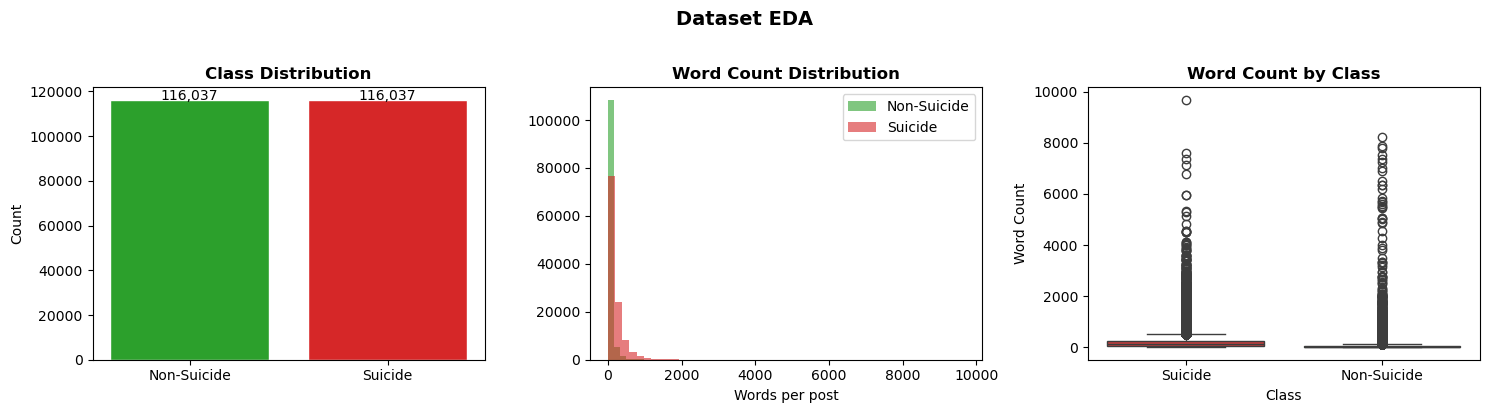


Text length stats:
          count   mean    std  min   25%    50%    75%     max
class                                                         
0      116037.0   61.2  139.3  2.0  19.0   31.0   60.0  8220.0
1      116037.0  202.7  255.3  1.0  60.0  127.0  251.0  9684.0


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Class distribution ---
counts = df[LABEL_COLUMN].value_counts()
axes[0].bar(["Non-Suicide", "Suicide"], [counts[0], counts[1]],
            color=["#2ca02c", "#d62728"], edgecolor="white")
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontsize=10)

# --- Text length distribution ---
df["text_len"] = df[TEXT_COLUMN].apply(lambda x: len(str(x).split()))
for label, color, name in [(0,"#2ca02c","Non-Suicide"),(1,"#d62728","Suicide")]:
    subset = df[df[LABEL_COLUMN]==label]["text_len"]
    axes[1].hist(subset, bins=50, alpha=0.6, color=color, label=name)
axes[1].set_title("Word Count Distribution", fontweight="bold")
axes[1].set_xlabel("Words per post"); axes[1].legend()

# --- Text length box plot ---
df_plot = df.copy()
df_plot["Class"] = df_plot[LABEL_COLUMN].map({0:"Non-Suicide",1:"Suicide"})
sns.boxplot(data=df_plot, x="Class", y="text_len",
            palette={"Non-Suicide":"#2ca02c","Suicide":"#d62728"}, ax=axes[2])
axes[2].set_title("Word Count by Class", fontweight="bold")
axes[2].set_ylabel("Word Count")

plt.suptitle("Dataset EDA", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nText length stats:\n{df.groupby(LABEL_COLUMN)['text_len'].describe().round(1)}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (659 > 512). Running this sequence through the model will result in indexing errors


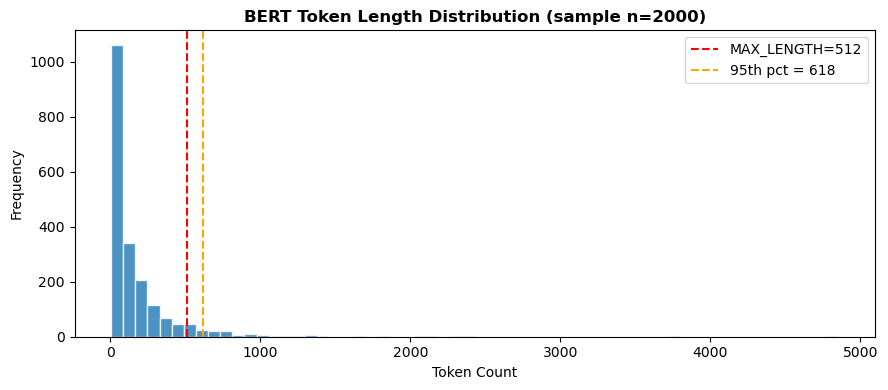

Posts exceeding MAX_LENGTH=512: 7.3%


In [4]:
# Token length analysis (using BERT tokenizer)
from transformers import AutoTokenizer
tokenizer_eda = AutoTokenizer.from_pretrained("bert-base-uncased")

sample = df[TEXT_COLUMN].sample(min(2000, len(df)), random_state=42)
token_lengths = [len(tokenizer_eda.encode(str(t), truncation=False)) for t in sample]

plt.figure(figsize=(9,4))
plt.hist(token_lengths, bins=60, color="#1f77b4", edgecolor="white", alpha=0.8)
plt.axvline(512, color="red", linestyle="--", linewidth=1.5, label="MAX_LENGTH=512")
plt.axvline(np.percentile(token_lengths,95), color="orange", linestyle="--",
            linewidth=1.5, label=f"95th pct = {int(np.percentile(token_lengths,95))}")
plt.xlabel("Token Count"); plt.ylabel("Frequency")
plt.title("BERT Token Length Distribution (sample n=2000)", fontweight="bold")
plt.legend(); plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_token_lengths.png", dpi=150)
plt.show()
pct_truncated = sum(1 for t in token_lengths if t > 512) / len(token_lengths) * 100
print(f"Posts exceeding MAX_LENGTH=512: {pct_truncated:.1f}%")

## 2.4 Train / Val / Test Split
Stratified split ensuring class balance is preserved in all three sets.
- **Train**: 70% | **Val**: 15% | **Test**: 15%

In [5]:
def split_dataset(df):
    X, y = df[TEXT_COLUMN].values, df[LABEL_COLUMN].values
    X_train, X_tmp, y_train, y_tmp = train_test_split(
        X, y, test_size=TEST_SIZE+VAL_SIZE, stratify=y, random_state=RANDOM_SEED)
    val_ratio = VAL_SIZE / (TEST_SIZE + VAL_SIZE)
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=1-val_ratio, stratify=y_tmp, random_state=RANDOM_SEED)
    return (X_train,y_train),(X_val,y_val),(X_test,y_test)

(X_train,y_train),(X_val,y_val),(X_test,y_test) = split_dataset(df)

print(f"{'Split':<10} {'Total':>8} {'Suicide':>10} {'Non-suicide':>13}")
print("-"*45)
for name,y in [("Train",y_train),("Val",y_val),("Test",y_test)]:
    s = y.sum(); n = len(y)-s
    print(f"{name:<10} {len(y):>8,} {s:>10,} ({s/len(y)*100:.0f}%) {n:>6,} ({n/len(y)*100:.0f}%)")

Split         Total    Suicide   Non-suicide
---------------------------------------------
Train       162,451     81,226 (50%) 81,225 (50%)
Val          34,811     17,405 (50%) 17,406 (50%)
Test         34,812     17,406 (50%) 17,406 (50%)


## 2.5 Class Weights
Since the dataset may be imbalanced, we compute inverse-frequency weights for the loss function.

In [6]:
def get_class_weights(y_train):
    weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
    tensor  = torch.tensor(weights, dtype=torch.float).to(DEVICE)
    print(f"Class weights → Non-Suicide: {weights[0]:.4f} | Suicide: {weights[1]:.4f}")
    return tensor

class_weights = get_class_weights(y_train)

Class weights → Non-Suicide: 1.0000 | Suicide: 1.0000


## 2.6 PyTorch Dataset & DataLoader
Custom `Dataset` class that tokenizes text on the fly and returns model-ready tensors.

In [ ]:
class SuicideDataset(Dataset):
    """
    PyTorch Dataset for suicidal ideation detection.
    Tokenizes text lazily (on __getitem__) to keep memory usage low.
    """
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LENGTH):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            # DistilBERT has no token_type_ids — return zeros as fallback
            "token_type_ids": enc.get("token_type_ids",
                              torch.zeros(self.max_len, dtype=torch.long)).squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.long),
        }


def get_dataloaders(model_name):
    """Factory: returns (train, val, test) DataLoaders + class_weights."""
    tokenizer    = AutoTokenizer.from_pretrained(model_name)
    train_ds     = SuicideDataset(X_train, y_train, tokenizer)
    val_ds       = SuicideDataset(X_val,   y_val,   tokenizer)
    test_ds      = SuicideDataset(X_test,  y_test,  tokenizer)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader, tokenizer

# Quick sanity check
print("Checking a batch from BERT DataLoader...")
_train, _val, _test, _tok = get_dataloaders("bert-base-uncased")
batch = next(iter(_train))
for k, v in batch.items():
    print(f"  {k:20s}: {v.shape}")
print("\nDataset & DataLoader ready.")